# Humanoid Plasticity Injection Experiments

The robot is **Humanoid** from MuJoCo — a 3D simulated figure that learns to walk.

Trying to induce plasticity for robot to be able to learn more!

---

## ⚙️ Setup — read this before running anything


### ☁️ Running on Google Colab

**1. Switch to a GPU runtime:**
> Runtime → Change runtime type → Hardware accelerator → **T4 GPU** → Save

**2. Run Step 0 first** and wait for `✅ Setup complete`.



## Step 0 — Colab Setup

> **Local users: skip this cell.**  
> **Colab users: run this cell first** and wait for `✅ Setup complete`.

In [ ]:
# ════════════════════════════════════════════════
# COLAB ONLY — local users skip this cell
# ════════════════════════════════════════════════
import subprocess, sys, os

REPO = 'pgss-L4R-IL-public'
if not os.path.isdir(REPO):
    r = subprocess.run(['git', 'clone', 'https://github.com/alokshah04/pgss-L4R-IL-public.git'],
                       capture_output=True, text=True)
    print(r.stdout or r.stderr)
else:
    print('Repo already cloned.')
if not os.getcwd().endswith(REPO):
    os.chdir(REPO)
print('Working directory:', os.getcwd())

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print('\n✅ Setup complete. Continue to Step 1.')


Cloning into 'pgss-L4R-IL-public'...

Working directory: /content/pgss-L4R-IL-public

✅ Setup complete. Continue to Step 1.


---
## Step 1 — Imports and Expert



In [ ]:
#you may see a `Could not deserialize lr_schedule` warning — ignore. The policy weights load fine
import gymnasium as gym
from huggingface_sb3 import load_from_hub
from stable_baselines3 import SAC
from sb3_contrib import TQC
import imageio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import Video, display

ENV_NAME    = 'Humanoid-v5'

checkpoint = load_from_hub("farama-minari/Humanoid-v5-TQC-expert", "humanoid-v5-TQC-expert.zip")
expert = TQC.load(checkpoint)
print('Expert policy loaded.')

env = gym.make(ENV_NAME)
print(f'Observation space: {env.observation_space}')   # what the robot sees
print(f'Action space:      {env.action_space}')        # what the robot does
env.close()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


humanoid-v5-TQC-expert.zip:   0%|          | 0.00/7.38M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1727: DeprecationWarning: hf_xet.download_files() is deprecated. Use XetSession().new_file_download_group().start_download_file() instead.
  xet_get(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:165: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  deserialized_object = cloudpickle.loads(base64_object)


Expert policy loaded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Observation space: Box(-inf, inf, (348,), float64)
Action space:      Box(-0.4, 0.4, (17,), float32)


### Step 1a — Video recorder

In [ ]:
# ════════════════════════════════════════════════
# LOCAL ONLY — Colab users skip this cell
# ════════════════════════════════════════════════
def record_policy(step_fn, env_name, path, max_steps=300, seed=1, fps=30):
    """Run step_fn(obs) -> action and save an MP4 using gymnasium's rgb_array renderer."""
    env = gym.make(env_name, render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)
    frames, total_reward = [], 0.0
    for _ in range(max_steps):
        action = step_fn(obs)
        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward
        frames.append(env.render())
        if done or truncated:
            break
    env.close()
    imageio.mimsave(path, frames, fps=fps)
    print(f'Saved {path}  |  reward: {total_reward:.1f}  |  frames: {len(frames)}')
    return total_reward

print('record_policy defined.')

record_policy defined.


### Step 1b — Watch the expert run (local only)

> **Colab users: skip this cell.**

In [ ]:
# ════════════════════════════════════════════════
# LOCAL ONLY — Colab users skip this cell
# ════════════════════════════════════════════════
def expert_step(obs):
    action, _ = expert.predict(obs, deterministic=True)
    return action

record_policy(expert_step, ENV_NAME, 'expert_demo.mp4')
display(Video('expert_demo.mp4', embed=True, width=600))

Saved expert_demo.mp4  |  reward: 2707.5  |  frames: 300


---
## Step 2 — Collect Demonstrations

In [ ]:
NUM_TRAJ      = 80
MAX_TIMESTEPS = 300
VAL_TRAJ      = 10   # held-out trajectories for validation

print(f'Collecting {NUM_TRAJ} expert trajectories...')

env = gym.make(ENV_NAME)
policy = TQC.load(checkpoint)
env.reset(seed=42)

all_trajectories = []
for ep in range(NUM_TRAJ):
    obs, _ = env.reset()
    traj = {'obs': [], 'acts': [], 'rewards': []}
    for _ in range(MAX_TIMESTEPS):
        traj['obs'].append(obs.copy())
        action, _ = policy.predict(obs, deterministic=True)
        traj['acts'].append(action)
        obs, reward, done, truncated, _ = env.step(action)
        traj['rewards'].append(reward)
        if done or truncated:
            break
    all_trajectories.append(traj)
env.close()

# Split into train and val
train_trajs = all_trajectories[:NUM_TRAJ - VAL_TRAJ]
val_trajs   = all_trajectories[NUM_TRAJ - VAL_TRAJ:]

print(f'Train trajectories: {len(train_trajs)}')
print(f'Val   trajectories: {len(val_trajs)}')

Train trajectories: 70
Val   trajectories: 10


In [ ]:
# Inspect one trajectory
traj0 = train_trajs[0]
obs0, acts0 = np.array(traj0['obs']), np.array(traj0['acts'])
print(f'Trajectory length: {len(traj0["obs"])} steps')
print(f'Observation shape: {obs0.shape}  (T x obs_dim)')
print(f'Action shape:      {acts0.shape}  (T x act_dim)')
print(f'Total reward:      {sum(traj0["rewards"]):.1f}')
print('\nFirst observation (what the robot sees at t=0):')
print(obs0[0])
print('\nFirst expert action (what the expert does at t=0):')
print(acts0[0])

Trajectory length: 300 steps
Observation shape: (300, 348)  (T x obs_dim)
Action shape:      (300, 17)  (T x act_dim)
Total reward:      2742.1

First observation (what the robot sees at t=0):
[ 1.39279505e+00  9.93998164e-01 -9.85275460e-03  5.73848755e-03
  3.29701713e-03  4.10330757e-03  5.61458062e-03 -8.21684489e-04
  1.37482392e-03 -7.20406004e-03 -7.70939853e-03  3.36805924e-03
 -5.78075877e-04  1.30472213e-03  5.29997715e-03  2.69436640e-03
  1.07158801e-03  1.18414321e-03 -3.92099804e-03 -9.38364331e-03
 -1.26565222e-03 -5.70830654e-03 -1.82942713e-03  7.06806147e-03
 -5.32121028e-03 -8.83394517e-03 -4.37232216e-03 -4.12812484e-03
  3.23833029e-03  1.14064305e-03  5.67796418e-03  3.28627081e-03
 -1.87226277e-03  6.28040769e-03 -6.66054160e-03 -9.54575854e-03
 -8.19904278e-03  4.44718701e-03 -7.62455395e-04 -6.77456442e-03
  2.08955021e-05 -6.95375795e-03  3.92640750e-03 -1.07687449e-03
 -2.37957548e-03  2.30484309e+00  2.28588785e+00  4.31735600e-02
  9.36269824e-04  4.0545155

---
## Step 3 — Build a Supervised Learning Dataset


In [ ]:
# ── Observation normalization shared by IL and PPO ───────────────────────────
# The reference CleanRL PPO wraps the env in NormalizeObservation, so the policy
# always sees ~zero-mean/unit-var observations. For the IL warm start to be valid
# in that PPO, the IL policy must be trained on the SAME normalized observations.
# We compute a FIXED mean/std once from the expert demonstrations (train split
# only) and reuse it verbatim: in IL training here, and as a frozen
# TransformObservation in the PPO env later. Fixed (not a running estimate) =
# reproducible and drift-free, so the obs distribution the IL actor learned is
# exactly the one PPO feeds it.
_all_obs = np.concatenate([np.array(t['obs']) for t in train_trajs], axis=0)
OBS_MEAN = _all_obs.mean(axis=0).astype(np.float32)
OBS_STD  = (_all_obs.std(axis=0) + 1e-8).astype(np.float32)
print(f'Obs normalization from demos: mean[:3]={OBS_MEAN[:3]}, std[:3]={OBS_STD[:3]}')

def normalize_obs(obs):
    """Fixed demo-derived normalization, then clip to +/-10 (matches the reference)."""
    return np.clip((np.asarray(obs, dtype=np.float32) - OBS_MEAN) / OBS_STD, -10.0, 10.0)


class TrajDataset(Dataset):
    """
    Converts a list of trajectories into a PyTorch Dataset of (obs, action) pairs.
    Observations are NORMALIZED with the fixed demo statistics so the learned
    policy lives in the same input space the PPO env will later provide.
    """
    def __init__(self, trajectories):
        obs_list, act_list = [], []
        for traj in trajectories:
            obs_list.extend(traj['obs'])
            act_list.extend(traj['acts'])
        obs_arr = normalize_obs(np.array(obs_list))
        self.inputs = torch.tensor(obs_arr, dtype=torch.float32)
        self.labels = torch.tensor(np.array(act_list), dtype=torch.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]


BATCH_SIZE = 256

train_dataset = TrajDataset(train_trajs)
val_dataset   = TrajDataset(val_trajs)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {len(train_dataset)}')
print(f'Val   samples: {len(val_dataset)}')

obs_batch, act_batch = next(iter(train_loader))
print(f'\nOne batch: observations {obs_batch.shape}, actions {act_batch.shape}')

OBS_DIM = obs_batch.shape[1]
ACT_DIM = act_batch.shape[1]
print(f'obs_dim = {OBS_DIM},  act_dim = {ACT_DIM}')

Obs normalization from demos: mean[:3]=[ 1.2526941   0.8374396  -0.11794598], std[:3]=[0.02989914 0.0789478  0.04498038]
Train samples: 20856
Val   samples: 3000

One batch: observations torch.Size([256, 348]), actions torch.Size([256, 17])
obs_dim = 348,  act_dim = 17


---
## Step 4 — Define the Policy Network


In [ ]:
class MLP(nn.Module):
    """
    The learned policy. Architecture is IDENTICAL to the reference CleanRL PPO
    actor_mean (Linear->LayerNorm->Tanh x2 -> Linear, 64 hidden units), so the
    trained weights load straight into the PPO agent with no mismatch.
    Input is the NORMALIZED observation (see previous cell).
    """
    def __init__(self, obs_dim, act_dim, hidden_size=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, act_dim),        # no LayerNorm on the output layer
        )

    def forward(self, x):
        return self.net(x)


HIDDEN_SIZE = 64
model = MLP(obs_dim=OBS_DIM, act_dim=ACT_DIM, hidden_size=HIDDEN_SIZE)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=348, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): Tanh()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=17, bias=True)
  )
)

Total parameters: 27,857


---
## Step 5 — Train the Policy

In [ ]:
EPOCHS = 500   # full schedule for a strong IL policy
LR     = 1e-3   #benchmark, found online
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training on: {DEVICE}')
#this takes 10 mins to run

model = model.to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in tqdm(range(EPOCHS), desc='Training'):
    # ── training pass ────────────────────────────────────────
    model.train()
    total_train = 0.0
    for obs, acts in train_loader:
      #this is the big training loop
        obs, acts = obs.to(DEVICE), acts.to(DEVICE)
        preds = model(obs)
        loss  = criterion(preds, acts)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train += loss.item() * obs.size(0)
    scheduler.step()
    train_losses.append(total_train / len(train_dataset))

    # ── validation pass (no gradients) ───────────────────────
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for obs, acts in val_loader:
            obs, acts = obs.to(DEVICE), acts.to(DEVICE)
            preds = model(obs)
            total_val += criterion(preds, acts).item() * obs.size(0)
    val_losses.append(total_val / len(val_dataset))

difference = np.array(train_losses) - np.array(val_losses)


print(f'Final train loss: {train_losses[-1]:.6f}')
print(f'Final val   loss: {val_losses[-1]:.6f}')
print(f'Difference between train and val: {difference[-1]:.6f}')
#added this to see how far off we are

# ── save the trained IL policy so Part 2 (PPO) can load it directly ──────────
IL_POLICY_PATH = 'il_policy.pt'
torch.save(model.state_dict(), IL_POLICY_PATH)
print(f'Saved IL policy to {IL_POLICY_PATH}')


Training on: cpu


Training: 100%|██████████| 500/500 [04:49<00:00,  1.73it/s]

Final train loss: 0.002270
Final val   loss: 0.003773
Difference between train and val: -0.001503
Saved IL policy to il_policy.pt


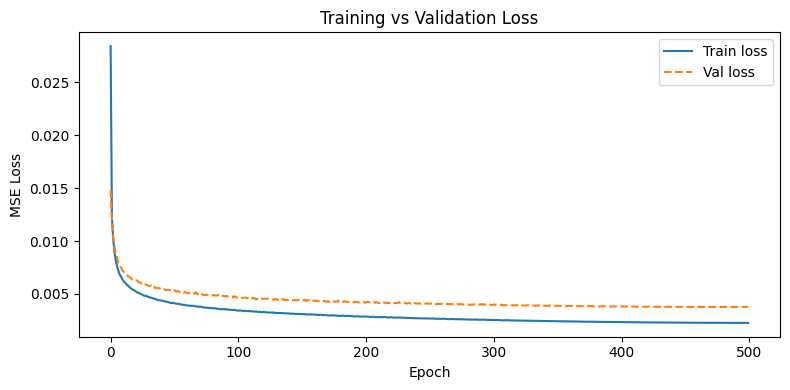

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout(); plt.savefig('training_loss.png', dpi=120); plt.show()

---
## Step 6 — Evaluate on Test Rollouts

In [ ]:
NUM_EVAL_TRAJ = 10
model = model.cpu().eval()

expert_returns  = []
learned_returns = []

rng = np.random.default_rng(0)
for _ in tqdm(range(NUM_EVAL_TRAJ), desc='Evaluating'):
    seed = int(rng.integers(0, 2**31))

    # ── expert rollout ───────────────────────────────────────
    env = gym.make(ENV_NAME)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    for _ in range(MAX_TIMESTEPS):
        action, _ = policy.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = env.step(action)
        ep_reward += reward
        if done or truncated: break
    env.close()
    expert_returns.append(ep_reward)

    # ── learned policy rollout ───────────────────────────────
    env = gym.make(ENV_NAME)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    with torch.no_grad():
        for _ in range(MAX_TIMESTEPS):
            obs_t  = torch.tensor(normalize_obs(obs), dtype=torch.float32).unsqueeze(0)
            action = model(obs_t).squeeze(0).numpy()
            obs, reward, done, truncated, _ = env.step(action)
            ep_reward += reward
            if done or truncated: break
    env.close()
    learned_returns.append(ep_reward)

expert_returns  = np.array(expert_returns)
learned_returns = np.array(learned_returns)

print(f'Expert  avg return: {expert_returns.mean():.1f} +/- {expert_returns.std():.1f}')
print(f'Learned avg return: {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
reward_gap = (expert_returns.mean() - learned_returns.mean()) / abs(expert_returns.mean())
print(f'Normalised reward gap: {reward_gap:.1%}')

Evaluating: 100%|██████████| 10/10 [00:06<00:00,  1.61it/s]

Expert  avg return: 2570.7 +/- 436.5
Learned avg return: 1562.6 +/- 723.8
Normalised reward gap: 39.2%


/tmp/ipykernel_4558/3202646983.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([expert_returns, learned_returns],
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


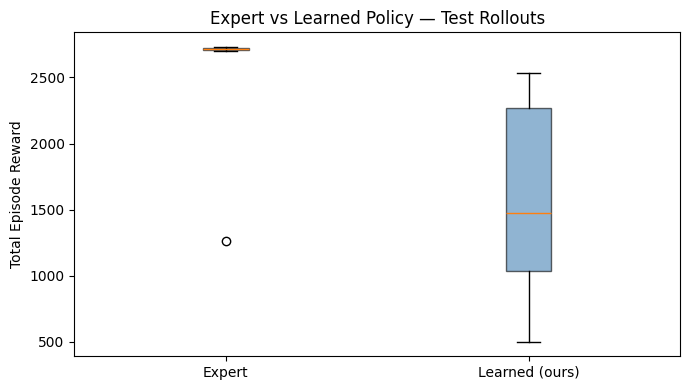

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([expert_returns, learned_returns],
           labels=['Expert', 'Learned (ours)'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Total Episode Reward'); ax.set_title('Expert vs Learned Policy — Test Rollouts')
plt.tight_layout(); plt.savefig('eval_rewards.png', dpi=120); plt.show()

---
# Part 2 — Fine-tuning the IL Policy with PPO


In [ ]:
# ── PPO (CleanRL) imports ─────────────────────────────────────────────────────
import random
import time
from types import SimpleNamespace
from collections import deque

from torch.distributions.normal import Normal

try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_AVAILABLE = True
except Exception:
    TENSORBOARD_AVAILABLE = False
    print('TensorBoard not available — training will still run, just without logging to runs/.')

print('Ready for RL training.')


Ready for RL training.


### Step A — PPO Hyperparameters


In [ ]:
args = SimpleNamespace(
    exp_name        = 'ppo_halfcheetah',
    seed            = 205,
    torch_deterministic = True,
    cuda            = True,
    track           = False,          # set True + `pip install wandb` for W&B logging
    wandb_project_name = 'cleanRL',
    wandb_entity    = None,
    capture_video   = False,

    # ── Environment ──────────────────────────────────────────────────────────
    env_id          = ENV_NAME,       # 'HalfCheetah-v5', from Step 1

    # ── Rollout collection ───────────────────────────────────────────────────
    total_timesteps = 500_000,        # CleanRL default is 1_000_000; trimmed for speed
    num_envs        = 4,
    num_steps       = 2048,

    # ── PPO update ───────────────────────────────────────────────────────────
    learning_rate   = 1e-4,           # lowered from 3e-4: warm start + Humanoid termination
                                      # make PPO fragile early; a smaller step preserves it
    anneal_lr       = True,
    gamma           = 0.99,
    gae_lambda      = 0.95,
    num_minibatches = 32,
    update_epochs   = 10,
    norm_adv        = True,
    clip_coef       = 0.2,
    clip_vloss      = True,
    ent_coef        = 0.0,
    vf_coef         = 0.5,
    max_grad_norm   = 0.5,
    target_kl       = 0.02,           # early-stop each update's epochs when the policy
                                      # moves too far — guards the warm start from collapse
)
args.batch_size = int(args.num_envs * args.num_steps)
args.minibatch_size = int(args.batch_size // args.num_minibatches)
num_updates = args.total_timesteps // args.batch_size

# ── Critic warm-up ───────────────────────────────────────────────────────────
# A behavior-cloned warm start gives us a competent ACTOR but no value function. At
# PPO update 1 the critic outputs noise, so advantages A = returns - V(s) are garbage
# and the very first policy step wrecks the warm-started actor before the critic
# catches up. We first FREEZE the actor, roll out the IL policy, and train ONLY the
# critic to predict returns — so V(s) is meaningful before any joint update.
CRITIC_WARMUP_STEPS   = 25_000        # env steps of frozen-actor rollout for critic fit
CRITIC_WARMUP_EPOCHS  = 8             # passes over the collected buffer
CRITIC_WARMUP_LR      = 1e-3          # critic-only LR (higher is fine; actor is frozen)

print(f'Batch size: {args.batch_size:,}   Minibatch size: {args.minibatch_size}')
print(f'Total updates: {num_updates}   ({args.total_timesteps/1e6:.2f}M env steps)')

Batch size: 8,192   Minibatch size: 256
Total updates: 61   (0.50M env steps)


### Step B — Vectorized Environments and the Actor-Critic



In [ ]:
def make_env(env_id, seed, idx, capture_video, run_name, gamma):
    """Env wrappers matching the CleanRL reference, EXCEPT observation
    normalization uses our FIXED demo-derived stats (OBS_MEAN/OBS_STD) instead of
    a running NormalizeObservation. That way the PPO env feeds the IL actor
    exactly the normalized-obs distribution it was trained on (warm start valid),
    while everything else — action clip, reward normalization, reward clip — is
    the standard reference recipe that keeps values ~O(1) and PPO stable."""
    def thunk():
        if capture_video and idx == 0:
            env = gym.make(env_id, render_mode='rgb_array')
        else:
            env = gym.make(env_id)
        env = gym.wrappers.FlattenObservation(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        if capture_video and idx == 0:
            env = gym.wrappers.RecordVideo(env, f'videos/{run_name}')
        env = gym.wrappers.ClipAction(env)
        # Fixed observation normalization (== the IL training transform).
        env = gym.wrappers.TransformObservation(
            env, lambda obs: normalize_obs(obs), observation_space=env.observation_space)
        # Reference reward handling: normalize + clip -> rewards/values ~O(1).
        env = gym.wrappers.NormalizeReward(env, gamma=gamma)
        env = gym.wrappers.TransformReward(env, lambda reward: np.clip(reward, -10, 10))
        env.action_space.seed(seed)
        return env
    return thunk


def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer


class Agent(nn.Module):
    """Actor-critic identical to the CleanRL reference (64-unit Tanh MLPs,
    orthogonal init, LayerNorm). The actor_mean matches the IL `MLP.net` exactly, so the IL
    weights load straight in. actor_logstd starts at -3.0 (std~0.05) instead of
    the reference's 0.0, to keep the first rollouts close to the deterministic IL
    policy (the whole point of warm-starting)."""
    def __init__(self, envs):
        super().__init__()
        obs_dim = np.array(envs.single_observation_space.shape).prod()
        act_dim = np.prod(envs.single_action_space.shape)
        h = HIDDEN_SIZE                      # single source of truth (set in the model cell)
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, h)),
            nn.LayerNorm(h),
            nn.Tanh(),
            layer_init(nn.Linear(h, h)),
            nn.LayerNorm(h),
            nn.Tanh(),
            layer_init(nn.Linear(h, 1), std=1.0),
        )
        # actor_mean SEQUENCE == MLP.net (Linear->LayerNorm->Tanh x2 -> Linear) at the
        # SAME width, so the IL warm start loads verbatim (LayerNorm params included).
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, h)),
            nn.LayerNorm(h),
            nn.Tanh(),
            layer_init(nn.Linear(h, h)),
            nn.LayerNorm(h),
            nn.Tanh(),
            layer_init(nn.Linear(h, act_dim), std=0.01),
        )
        self.actor_logstd = nn.Parameter(torch.ones(1, act_dim) * -3.0)

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        action_mean = self.actor_mean(x)
        action_logstd = self.actor_logstd.expand_as(action_mean)
        action_std = torch.exp(action_logstd)
        probs = Normal(action_mean, action_std)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action).sum(1), probs.entropy().sum(1), self.critic(x)


print('make_env, layer_init, Agent defined.')

make_env, layer_init, Agent defined.


### Step B.5 — Plasticity Injection Implementation

In [ ]:
class InjectedHead(nn.Module):
    """Same architecture as your IL MLP.net (Linear-Tanh-Linear-Tanh-Linear).
    Used twice: once as the trainable psi, once as its frozen twin."""
    def __init__(self, obs_dim, act_dim, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, act_dim),
        )
    def forward(self, x):
        return self.net(x)


class InjectedActor(nn.Module):
    """action(s) = frozen_baseline(s) + psi_trainable(s) - psi_frozen_twin(s)
    frozen_baseline: your already-trained IL policy, requires_grad=False forever.
    psi_trainable:   fresh random init, the ONLY thing PPO is allowed to update.
    psi_frozen_twin: identical init to psi_trainable, requires_grad=False forever.
    At construction time psi_trainable == psi_frozen_twin exactly, so this starts
    out function-identical to frozen_baseline alone."""
    def __init__(self, frozen_baseline, obs_dim, act_dim, hidden_size=64, psi_seed=1000):
        super().__init__()
        self.frozen_baseline = frozen_baseline
        for p in self.frozen_baseline.parameters():
            p.requires_grad = False
        self.frozen_baseline.eval()

        torch.manual_seed(psi_seed)  # separate seed from IL's 42, so psi's random init doesn't collide
        self.psi_trainable = InjectedHead(obs_dim, act_dim, hidden_size)

        self.psi_frozen_twin = InjectedHead(obs_dim, act_dim, hidden_size)
        self.psi_frozen_twin.load_state_dict(self.psi_trainable.state_dict())  # exact same init
        for p in self.psi_frozen_twin.parameters():
            p.requires_grad = False
        self.psi_frozen_twin.eval()

    def forward(self, x):
        with torch.no_grad():
            base_out = self.frozen_baseline(x)
            twin_out = self.psi_frozen_twin(x)
        return base_out + self.psi_trainable(x) - twin_out


print('InjectedHead, InjectedActor defined.')


InjectedHead, InjectedActor defined.


### Step C — Train!

In [ ]:
run_name = f'{args.env_id}__{args.exp_name}__{args.seed}__{int(time.time())}'

if args.track:
    import wandb
    wandb.init(project=args.wandb_project_name, entity=args.wandb_entity,
               sync_tensorboard=True, config=vars(args), name=run_name,
               monitor_gym=True, save_code=True)

if TENSORBOARD_AVAILABLE:
    writer = SummaryWriter(f'runs/{run_name}')
    writer.add_text('hyperparameters',
        '|param|value|\n|-|-|\n%s' % ('\n'.join([f'|{k}|{v}|' for k, v in vars(args).items()])))
else:
    class _NoOpWriter:
        def add_scalar(self, *a, **k): pass
        def add_text(self, *a, **k): pass
        def close(self): pass
    writer = _NoOpWriter()

# TRY NOT TO MODIFY: seeding
random.seed(args.seed)
np.random.seed(args.seed)
torch.manual_seed(args.seed)
torch.backends.cudnn.deterministic = args.torch_deterministic

device = torch.device('cuda' if torch.cuda.is_available() and args.cuda else 'cpu')
print(f'Training on: {device}')

# env setup
envs = gym.vector.SyncVectorEnv(
    [make_env(args.env_id, args.seed + i, i, args.capture_video, run_name, args.gamma) for i in range(args.num_envs)]
)
assert isinstance(envs.single_action_space, gym.spaces.Box), 'only continuous action space is supported'

agent = Agent(envs).to(device)

# ── Function-preserving injection: replace actor_mean with InjectedActor ─────
_obs_dim = int(np.array(envs.single_observation_space.shape).prod())
_act_dim = int(np.prod(envs.single_action_space.shape))

try:
    _frozen_il = MLP(obs_dim=_obs_dim, act_dim=_act_dim, hidden_size=HIDDEN_SIZE)
    _frozen_il.net.load_state_dict(model.net.state_dict())
    print('Loaded IL weights into frozen baseline (from in-memory model).')
except NameError:
    _frozen_il = MLP(obs_dim=_obs_dim, act_dim=_act_dim, hidden_size=HIDDEN_SIZE)
    _frozen_il.load_state_dict(torch.load('il_policy.pt', map_location=device))
    print('Loaded IL weights into frozen baseline (from il_policy.pt).')

agent.actor_mean = InjectedActor(frozen_baseline=_frozen_il, obs_dim=_obs_dim, act_dim=_act_dim,
                                  hidden_size=HIDDEN_SIZE, psi_seed=1000).to(device)

# Sanity check: injected actor must be function-identical to frozen baseline right now.
with torch.no_grad():
    _test_obs = torch.randn(32, _obs_dim).to(device)
    _diff = (agent.actor_mean(_test_obs) - _frozen_il(_test_obs)).abs().max().item()
    print(f'[sanity] max |injected_actor(s) - frozen_baseline(s)| at init: {_diff:.8f}  (should be ~0.0)')

# Quick sanity: deterministic rollout of the loaded actor in the (wrapped) env.
with torch.no_grad():
    _o, _ = envs.reset(seed=args.seed + 123)
    _o = torch.Tensor(_o).to(device); _tot = np.zeros(args.num_envs)
    for _ in range(1000):
        _a = agent.actor_mean(_o)
        _o2, _r, _te, _tr, _ = envs.step(_a.cpu().numpy())
        _tot += _r; _o = torch.Tensor(_o2).to(device)
    print(f'[sanity] loaded-actor deterministic return/env (normalized-reward scale): {_tot.mean():.1f}')

# ── Critic warm-up: freeze actor, fit V(s) to returns under the IL policy ─────
# This is the fix for "warm-starting does not help": without it the cold critic's
# garbage advantages erase the warm start in the first few updates. We collect a
# buffer of (obs, discounted return-to-go) by rolling out the (noisy) warm-started
# policy, then regress the critic onto it. Only critic params are updated here.
if CRITIC_WARMUP_STEPS > 0:
    print(f'Critic warm-up: {CRITIC_WARMUP_STEPS:,} steps, actor frozen ...')
    cw_optimizer = optim.Adam(agent.critic.parameters(), lr=CRITIC_WARMUP_LR, eps=1e-5)
    cw_obs, cw_rew, cw_done = [], [], []
    _o, _ = envs.reset(seed=args.seed + 7)
    _o = torch.Tensor(_o).to(device)
    steps_needed = CRITIC_WARMUP_STEPS // args.num_envs
    with torch.no_grad():
        for _ in tqdm(range(steps_needed), desc='  collecting', leave=False):
            cw_obs.append(_o.clone())
            # sample actions from the warm-started stochastic policy (exploration on)
            a, _, _, _ = agent.get_action_and_value(_o)
            _o2, r, term, trunc, _ = envs.step(a.cpu().numpy())
            cw_rew.append(torch.tensor(r, dtype=torch.float32, device=device))
            cw_done.append(torch.tensor(np.logical_or(term, trunc), dtype=torch.float32, device=device))
            _o = torch.Tensor(_o2).to(device)
        # bootstrap value for the final state
        last_val = agent.get_value(_o).reshape(-1)
    # compute discounted return-to-go, resetting at episode boundaries (Humanoid
    # terminates!) — this is what makes the critic target correct on a terminating env
    T = len(cw_obs)
    cw_ret = [None] * T
    running = last_val
    for t in reversed(range(T)):
        running = cw_rew[t] + args.gamma * running * (1.0 - cw_done[t])
        cw_ret[t] = running
    Xb = torch.cat(cw_obs, dim=0)                       # [T*num_envs, obs_dim]
    Yb = torch.cat(cw_ret, dim=0)                       # [T*num_envs]
    n = Xb.shape[0]; mb = 512
    for ep in range(CRITIC_WARMUP_EPOCHS):
        idx = torch.randperm(n, device=device)
        tot = 0.0
        for s in range(0, n, mb):
            j = idx[s:s+mb]
            v = agent.get_value(Xb[j]).view(-1)
            vloss = ((v - Yb[j]) ** 2).mean()
            cw_optimizer.zero_grad(); vloss.backward()
            nn.utils.clip_grad_norm_(agent.critic.parameters(), args.max_grad_norm)
            cw_optimizer.step()
            tot += vloss.item() * len(j)
        print(f'  critic warm-up epoch {ep+1}/{CRITIC_WARMUP_EPOCHS}  MSE={tot/n:.3f}')
    # explained variance of the warmed critic (1.0 = perfect, 0 = predicts mean)
    with torch.no_grad():
        yp = agent.get_value(Xb).view(-1).cpu().numpy(); yt = Yb.cpu().numpy()
        ev = 1 - np.var(yt - yp) / (np.var(yt) + 1e-8)
    print(f'  critic warm-up done. explained_variance={ev:.3f} (want > 0)')

trainable_params = [p for p in agent.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=args.learning_rate, eps=1e-5)
print(f'Trainable params: {sum(p.numel() for p in trainable_params):,}  '
      f'(total incl. frozen: {sum(p.numel() for p in agent.parameters()):,})')

# ALGO Logic: Storage setup
obs      = torch.zeros((args.num_steps, args.num_envs) + envs.single_observation_space.shape).to(device)
actions  = torch.zeros((args.num_steps, args.num_envs) + envs.single_action_space.shape).to(device)
logprobs = torch.zeros((args.num_steps, args.num_envs)).to(device)
rewards  = torch.zeros((args.num_steps, args.num_envs)).to(device)
dones    = torch.zeros((args.num_steps, args.num_envs)).to(device)
values   = torch.zeros((args.num_steps, args.num_envs)).to(device)

# TRY NOT TO MODIFY: start the game
global_step = 0
start_time = time.time()
next_obs, _ = envs.reset(seed=args.seed)
next_obs = torch.Tensor(next_obs).to(device)
next_done = torch.zeros(args.num_envs).to(device)

episodic_returns_rl = []
policy_losses_rl = [] # Initialize list for policy losses
value_losses_rl = []  # Initialize list for value losses
approx_kls_rl = []    # Initialize list for approximate KL divergences
recent_returns = deque(maxlen=20)

pbar = tqdm(range(1, num_updates + 1), desc='PPO training')
for update in pbar:
    if args.anneal_lr:
        frac = 1.0 - (update - 1.0) / num_updates
        optimizer.param_groups[0]['lr'] = frac * args.learning_rate

    for step in range(0, args.num_steps):
        global_step += 1 * args.num_envs
        obs[step] = next_obs
        dones[step] = next_done

        with torch.no_grad():
            action, logprob, _, value = agent.get_action_and_value(next_obs)
            values[step] = value.flatten()
        actions[step] = action
        logprobs[step] = logprob

        next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())
        next_done = np.logical_or(terminations, truncations)
        rewards[step] = torch.tensor(reward).to(device).view(-1)
        next_obs, next_done = torch.Tensor(next_obs).to(device), torch.Tensor(next_done).to(device)

        # Gymnasium 1.x reports finished episodes via "episode"/"_episode".
        if 'episode' in infos:
            for i, finished in enumerate(infos['_episode']):
                if finished:
                    ep_ret = float(infos['episode']['r'][i]); ep_len = int(infos['episode']['l'][i])
                    episodic_returns_rl.append(ep_ret); recent_returns.append(ep_ret)
                    writer.add_scalar('charts/episodic_return', ep_ret, global_step)
                    writer.add_scalar('charts/episodic_length', ep_len, global_step)

    if recent_returns:
        pbar.set_postfix({'steps': f'{global_step/1e6:.2f}M', 'ret': f'{np.mean(recent_returns):.0f}'})

    # bootstrap value if not done  (reference GAE, verbatim)
    with torch.no_grad():
        next_value = agent.get_value(next_obs).reshape(1, -1)
        advantages = torch.zeros_like(rewards).to(device)
        lastgaelam = 0
        for t in reversed(range(args.num_steps)):
            if t == args.num_steps - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones[t + 1]
                nextvalues = values[t + 1]
            delta = rewards[t] + args.gamma * nextvalues * nextnonterminal - values[t]
            advantages[t] = lastgaelam = delta + args.gamma * args.gae_lambda * nextnonterminal * lastgaelam
        returns = advantages + values

    # flatten the batch
    b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
    b_logprobs = logprobs.reshape(-1)
    b_actions = actions.reshape((-1,) + envs.single_action_space.shape)
    b_advantages = advantages.reshape(-1)
    b_returns = returns.reshape(-1)
    b_values = values.reshape(-1)

    # Optimizing the policy and value network (reference, verbatim)
    b_inds = np.arange(args.batch_size)
    clipfracs = []
    for epoch in range(args.update_epochs):
        np.random.shuffle(b_inds)
        for start in range(0, args.batch_size, args.minibatch_size):
            end = start + args.minibatch_size
            mb_inds = b_inds[start:end]

            _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb_inds], b_actions[mb_inds])
            logratio = newlogprob - b_logprobs[mb_inds]
            ratio = logratio.exp()

            with torch.no_grad():
                old_approx_kl = (-logratio).mean()
                approx_kl = ((ratio - 1) - logratio).mean()
                clipfracs += [((ratio - 1.0).abs() > args.clip_coef).float().mean().item()]

            mb_advantages = b_advantages[mb_inds]
            if args.norm_adv:
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - args.clip_coef, 1 + args.clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            newvalue = newvalue.view(-1)
            if args.clip_vloss:
                v_loss_unclipped = (newvalue - b_returns[mb_inds]) ** 2
                v_clipped = b_values[mb_inds] + torch.clamp(
                    newvalue - b_values[mb_inds], -args.clip_coef, args.clip_coef)
                v_loss_clipped = (v_clipped - b_returns[mb_inds]) ** 2
                v_loss_max = torch.max(v_loss_unclipped, v_loss_clipped)
                v_loss = 0.5 * v_loss_max.mean()
            else:
                v_loss = 0.5 * ((newvalue - b_returns[mb_inds]) ** 2).mean()

            entropy_loss = entropy.mean()
            loss = pg_loss - args.ent_coef * entropy_loss + v_loss * args.vf_coef

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), args.max_grad_norm)
            optimizer.step()

        if args.target_kl is not None and approx_kl > args.target_kl:
            break

    y_pred, y_true = b_values.cpu().numpy(), b_returns.cpu().numpy()
    var_y = np.var(y_true)
    explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y

    writer.add_scalar('charts/learning_rate', optimizer.param_groups[0]['lr'], global_step)
    writer.add_scalar('losses/value_loss', v_loss.item(), global_step)
    writer.add_scalar('losses/policy_loss', pg_loss.item(), global_step)
    writer.add_scalar('losses/entropy', entropy_loss.item(), global_step)
    writer.add_scalar('losses/approx_kl', approx_kl.item(), global_step)
    writer.add_scalar('losses/clipfrac', np.mean(clipfracs), global_step)
    writer.add_scalar('losses/explained_variance', explained_var, global_step)

    policy_losses_rl.append(pg_loss.item())
    value_losses_rl.append(v_loss.item())
    approx_kls_rl.append(approx_kl.item())

envs.close()
writer.close()

torch.save(agent.state_dict(), 'ppo_halfcheetah.pt')
print(f'\nTraining complete in {(time.time() - start_time)/60:.1f} min. Saved ppo_halfcheetah.pt')

Training on: cpu
Loaded IL weights into frozen baseline (from in-memory model).
[sanity] max |injected_actor(s) - frozen_baseline(s)| at init: 0.00000006  (should be ~0.0)
[sanity] loaded-actor deterministic return/env (normalized-reward scale): 59.4
Critic warm-up: 25,000 steps, actor frozen ...


  critic warm-up epoch 1/8  MSE=0.455
  critic warm-up epoch 2/8  MSE=0.234
  critic warm-up epoch 3/8  MSE=0.215
  critic warm-up epoch 4/8  MSE=0.206
  critic warm-up epoch 5/8  MSE=0.201
  critic warm-up epoch 6/8  MSE=0.196
  critic warm-up epoch 7/8  MSE=0.194
  critic warm-up epoch 8/8  MSE=0.189
  critic warm-up done. explained_variance=0.615 (want > 0)
Trainable params: 54,435  (total incl. frozen: 109,893)


PPO training: 100%|██████████| 61/61 [13:21<00:00, 13.14s/it, steps=0.50M, ret=3216]


Training complete in 13.4 min. Saved ppo_halfcheetah.pt


### Step D — Evaluate and Compare: Expert vs IL vs PPO


In [ ]:
# ══════════════════════════════════════════════════════════════════
# ONE shared evaluator for all three policies.
# ──────────────────────────────────────────────────────────────────
# Here we evaluate
# Expert, IL, and PPO with the SAME function and the SAME horizon so every number
# and plot is directly comparable.
# ══════════════════════════════════════════════════════════════════
EVAL_MAX_STEPS = 1000   # HalfCheetah\'s native episode length (matches the PPO training curve)

def evaluate(step_fn, env_id, num_episodes=10, max_steps=EVAL_MAX_STEPS, seed=999):
    """Roll out step_fn(obs)->action deterministically and return per-episode total rewards."""
    returns = []
    for ep in range(num_episodes):
        env = gym.make(env_id)
        obs, _ = env.reset(seed=seed + ep)
        ep_ret = 0.0
        for _ in range(max_steps):
            action = step_fn(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_ret += reward
            if terminated or truncated:
                break
        env.close()
        returns.append(ep_ret)
    return np.array(returns)

# per-policy action functions (all deterministic / mean action)
def expert_step_fn(obs):
    action, _ = policy.predict(obs, deterministic=True)
    return action

def il_step_fn(obs):
    with torch.no_grad():
        obs_t = torch.tensor(normalize_obs(obs), dtype=torch.float32).unsqueeze(0)
        return model(obs_t).squeeze(0).numpy()

def ppo_step_fn(obs):
    with torch.no_grad():
        obs_t = torch.tensor(normalize_obs(obs), dtype=torch.float32, device=device).unsqueeze(0)
        return agent.actor_mean(obs_t).squeeze(0).cpu().numpy()

agent.eval()
expert_returns  = evaluate(expert_step_fn, ENV_NAME, num_episodes=NUM_EVAL_TRAJ)
learned_returns = evaluate(il_step_fn,     ENV_NAME, num_episodes=NUM_EVAL_TRAJ)
ppo_returns     = evaluate(ppo_step_fn,    ENV_NAME, num_episodes=NUM_EVAL_TRAJ)
agent.train()

print(f'(all evaluated over {EVAL_MAX_STEPS}-step episodes, same seeds)\n')
print(f'Expert avg return: {expert_returns.mean():.1f} +/- {expert_returns.std():.1f}')
print(f'IL     avg return: {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
print(f'PPO    avg return: {ppo_returns.mean():.1f} +/- {ppo_returns.std():.1f}')


(all evaluated over 1000-step episodes, same seeds)

Expert avg return: 9745.7 +/- 2766.5
IL     avg return: 1799.5 +/- 1359.0
PPO    avg return: 4466.6 +/- 2419.4


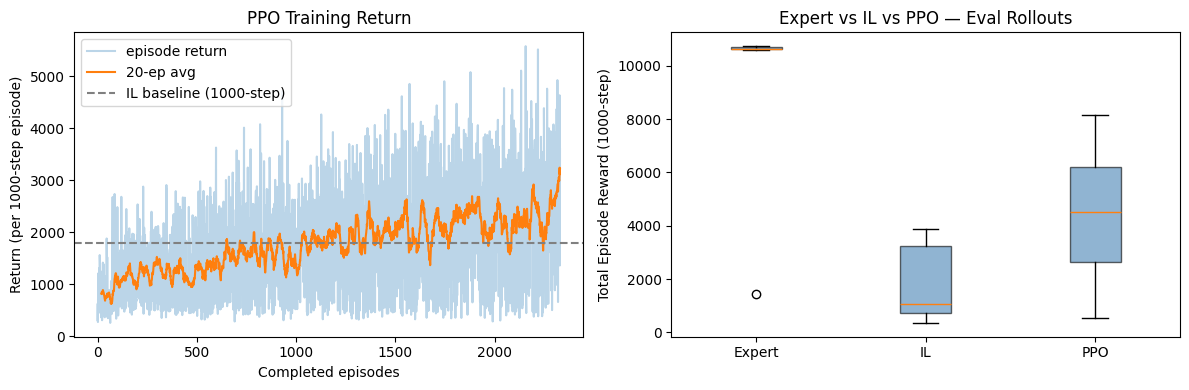

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


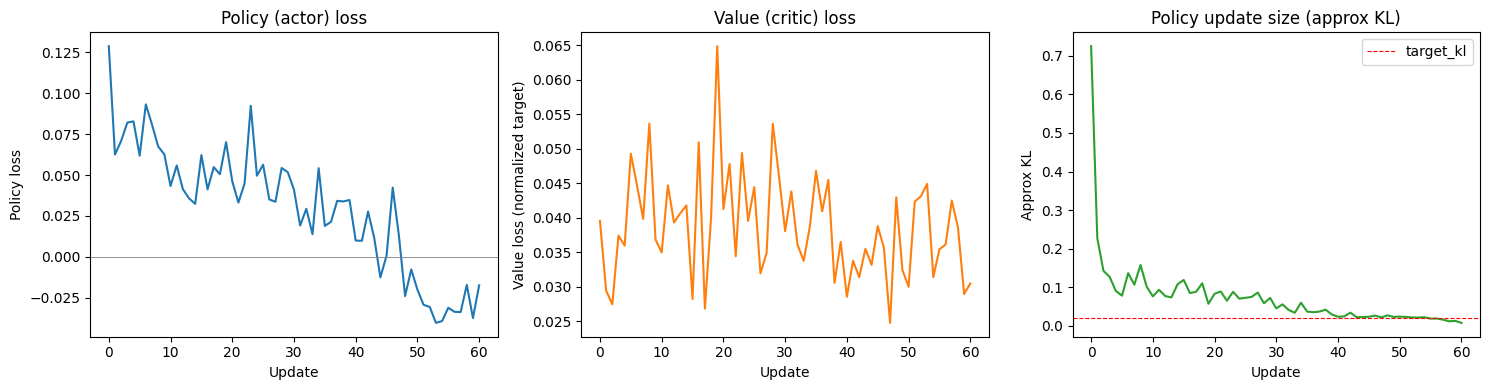

Expert avg return: 9745.7 +/- 2766.5
IL  eval return:  1799.5 +/- 1359.0
PPO eval return:  4466.6 +/- 2419.4
Delta (PPO - IL): +2667.1


In [ ]:
# ── Row 1: training return + eval comparison ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(episodic_returns_rl, alpha=0.3, label='episode return')
W = 20
if len(episodic_returns_rl) >= W:
    smooth = np.convolve(episodic_returns_rl, np.ones(W) / W, mode='valid')
    axes[0].plot(range(W - 1, len(episodic_returns_rl)), smooth, label=f'{W}-ep avg')
# IL baseline is now measured over the SAME 1000-step horizon as the training
# episodes (see the shared evaluate() in Step D), so this line is comparable.
axes[0].axhline(learned_returns.mean(), color='gray', linestyle='--', label='IL baseline (1000-step)')
axes[0].set_xlabel('Completed episodes'); axes[0].set_ylabel('Return (per 1000-step episode)')
axes[0].set_title('PPO Training Return'); axes[0].legend()

axes[1].boxplot(
    [expert_returns, learned_returns, ppo_returns],
    tick_labels=['Expert', 'IL', 'PPO'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
)
axes[1].set_ylabel('Total Episode Reward (1000-step)')
axes[1].set_title('Expert vs IL vs PPO — Eval Rollouts')

plt.tight_layout()
plt.savefig('il_vs_ppo_comparison.png', dpi=120)
plt.show()

# ── Row 2: PPO optimization diagnostics (policy loss, value loss, approx KL) ──
fig2, ax2 = plt.subplots(1, 3, figsize=(15, 4))

ax2[0].plot(policy_losses_rl, color='tab:blue')
ax2[0].set_xlabel('Update'); ax2[0].set_ylabel('Policy loss')
ax2[0].set_title('Policy (actor) loss'); ax2[0].axhline(0, color='gray', lw=0.6)

ax2[1].plot(value_losses_rl, color='tab:orange')
ax2[1].set_xlabel('Update'); ax2[1].set_ylabel('Value loss (normalized target)')
ax2[1].set_title('Value (critic) loss')

ax2[2].plot(approx_kls_rl, color='tab:green')
ax2[2].axhline(args.target_kl if args.target_kl is not None else 0.0,
               color='red', linestyle='--', lw=0.8,
               label=('target_kl' if args.target_kl is not None else None))
ax2[2].set_xlabel('Update'); ax2[2].set_ylabel('Approx KL')
ax2[2].set_title('Policy update size (approx KL)')
if args.target_kl is not None:
    ax2[2].legend()

plt.tight_layout()
plt.savefig('ppo_losses.png', dpi=120)
plt.show()

print(f'Expert avg return: {expert_returns.mean():.1f} +/- {expert_returns.std():.1f}')
print(f'IL  eval return:  {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
print(f'PPO eval return:  {ppo_returns.mean():.1f} +/- {ppo_returns.std():.1f}')
print(f'Delta (PPO - IL): {ppo_returns.mean() - learned_returns.mean():+.1f}')


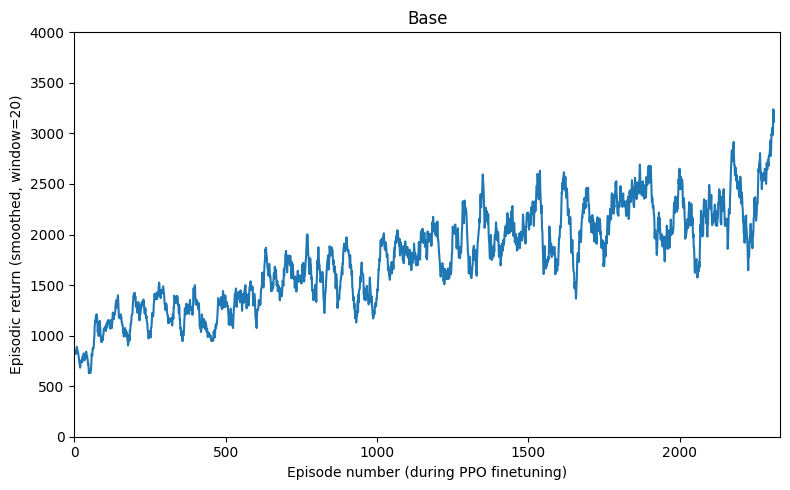

In [ ]:
#using this to see how our learning rate works
import numpy as np
import matplotlib.pyplot as plt

def smooth(x, window=20):
    return np.convolve(x, np.ones(window)/window, mode='valid')

curve = np.array(episodic_returns_rl)

plt.figure(figsize=(8, 5))
plt.plot(smooth(curve))
plt.xlabel('Episode number (during PPO finetuning)')
plt.ylabel('Episodic return (smoothed, window=20)')
plt.title('Base')       # change to "Base" or "L2-Init" in each notebook
plt.ylim(0, 4000)                       # SAME in both notebooks -- don't let it auto-scale
plt.xlim(0, len(curve))                  # check this matches roughly between runs too
plt.tight_layout()
plt.savefig('ppo_curve.png', dpi=120)
plt.show()